# Analyse météorologique de la côte au large du CPE La Ramée

Le point d'intérêt se situe à la latitude 47.366445362339576 et à longitude -61.87199621249825.

In [1]:
from pathlib import Path

import polars as pl

from src.analysis import (
    create_mean_residual_life_fig,
    extract_storms,
    fit_storms,
)
from src.data import (
    combine_to_ice_cover,
    read_era5_data,
    read_fetch,
    read_weather_data,
)
from src.figs import (
    create_fetch_wind_rose,
    create_ice_cover_plot,
    create_qq_plot,
    create_storm_intensity_fig,
    create_storm_wind_rose,
    create_storm_years_fig,
    create_wind_rose,
)

In [2]:
figures_dir = Path("..") / "figures"
figures_dir.mkdir(exist_ok=True)

In [3]:
closest, latest = await read_weather_data()
hourly_era5, monthly_era5 = await read_era5_data(
    closest["datetime"].min(), latest["datetime"].max()
)
latest = combine_to_ice_cover(latest, monthly_era5)
fetch = read_fetch()

In [37]:
print("Station la plus proche")
print(f"  station id: {closest[0, 'station_id']}")
print(f"  distance: {closest[0, 'distance']/1000:.2f} km")
print(
    f"  années de collecte: {closest[0, 'datetime'].year} - {closest[-1, 'datetime'].year}"
)
print("Station récente")
print(f"  station id: {latest[0, 'station_id']}")
print(f"  distance: {latest[0, 'distance']/1000:.2f} km")
print(
    f"  années de collecte: {latest[0, 'datetime'].year} - {latest[-1, 'datetime'].year}"
)

Station la plus proche
  station id: 7052960
  distance: 1.92 km
  années de collecte: 1953 - 1983
Station récente
  station id: 7053KGR
  distance: 9.83 km
  années de collecte: 1993 - 2026


## Détermination du biais et choix de la station

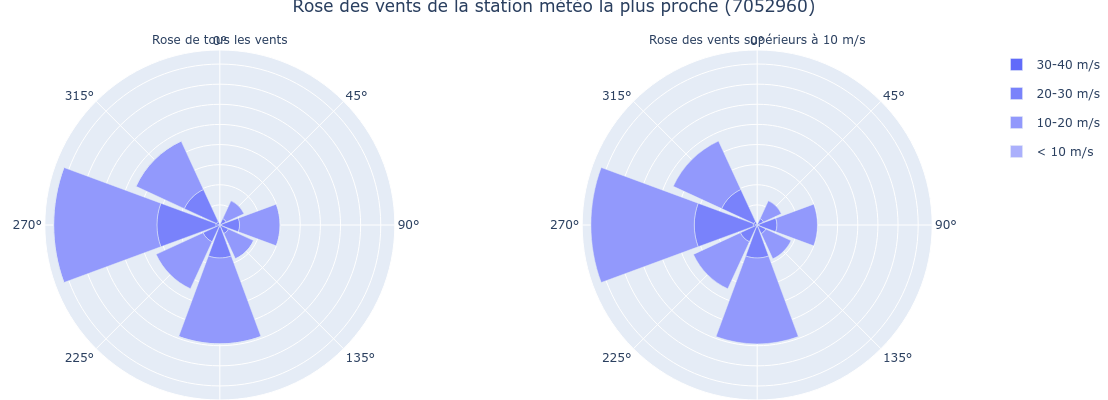

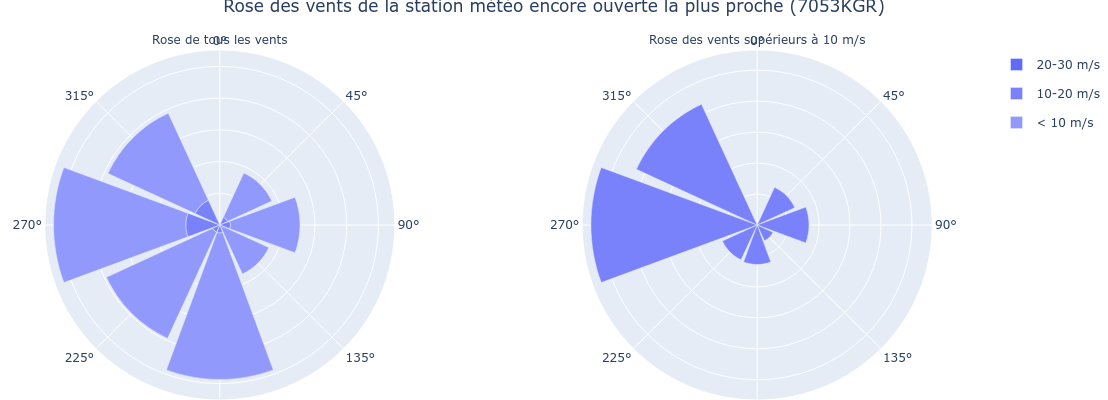

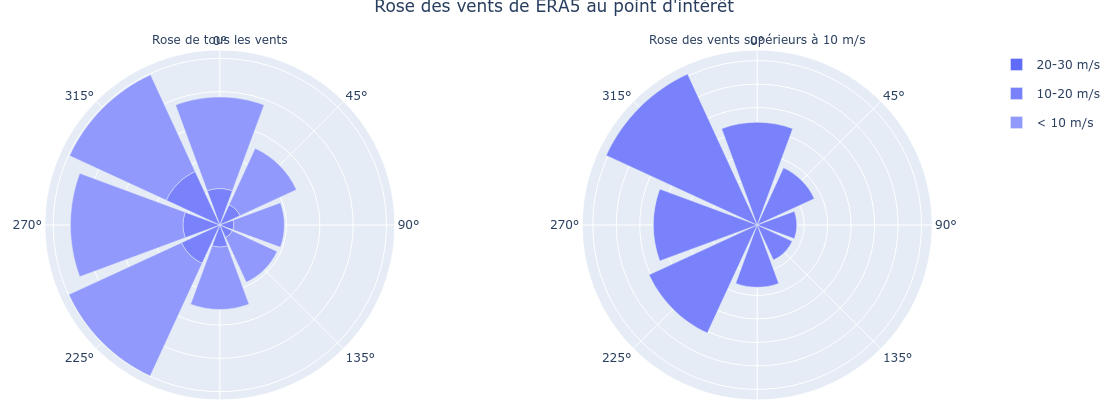

In [50]:
closest_fig = create_wind_rose(
    closest,
    title=f"Rose des vents de la station météo la plus proche ({closest[0,'station_id']})",
)
latest_fig = create_wind_rose(
    latest,
    title=f"Rose des vents de la station météo encore ouverte la plus proche ({latest[0,'station_id']})",
)
era5_fig = create_wind_rose(
    hourly_era5, title="Rose des vents de ERA5 au point d'intérêt"
)
closest_fig.write_image(figures_dir / "closest_rose_des_vents.svg")
latest_fig.write_image(figures_dir / "latest_rose_des_vents.svg")
era5_fig.write_image(figures_dir / "era5_rose_des_vents.svg")
closest_fig.show()
latest_fig.show()
era5_fig.show()

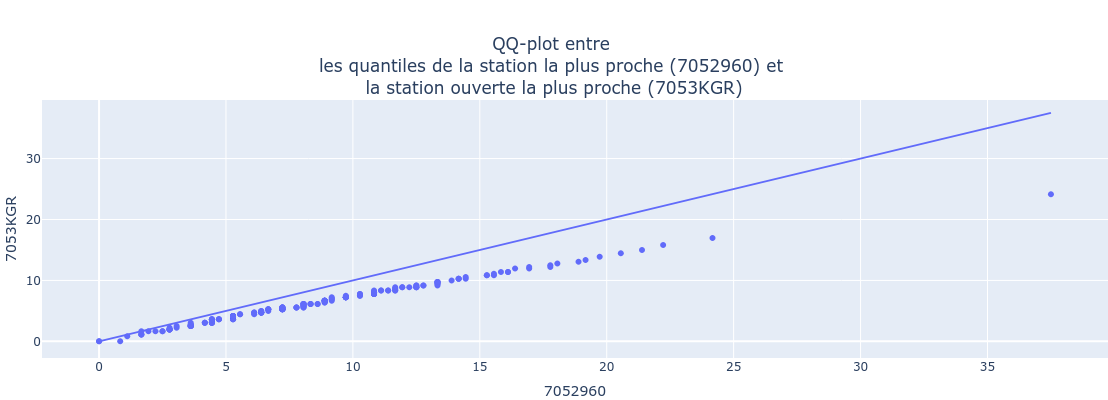

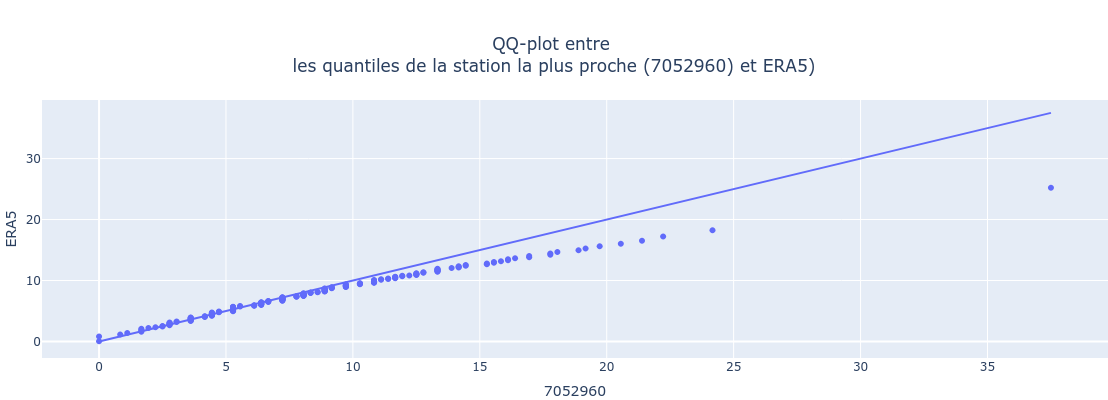

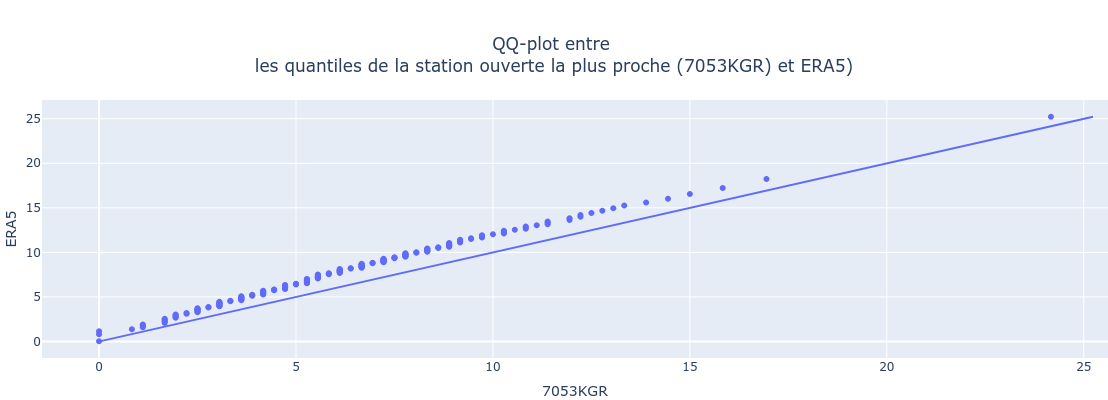

In [51]:
closest_latest_fig = create_qq_plot(
    closest["wind_speed"].alias(closest[0, "station_id"]),
    latest["wind_speed"].alias(latest[0, "station_id"]),
    title=f"QQ-plot entre <br>les quantiles de la station la plus proche ({closest[0,'station_id']}) et <br>la station ouverte la plus proche ({latest[0, 'station_id']})",
)
closest_era5_fig = create_qq_plot(
    closest["wind_speed"].alias(closest[0, "station_id"]),
    hourly_era5["wind_speed"].alias("ERA5"),
    title=f"QQ-plot entre <br>les quantiles de la station la plus proche ({closest[0,'station_id']}) et ERA5)",
)
latest_era5_fig = create_qq_plot(
    latest["wind_speed"].alias(latest[0, "station_id"]),
    hourly_era5["wind_speed"].alias("ERA5"),
    title=f"QQ-plot entre <br>les quantiles de la station ouverte la plus proche ({latest[0,'station_id']}) et ERA5)",
)
closest_latest_fig.write_image(figures_dir / "closest_latest_qq.svg")
closest_era5_fig.write_image(figures_dir / "closest_era5_qq.svg")
latest_era5_fig.write_image(figures_dir / "latest_era5_qq.svg")
closest_latest_fig.show()
closest_era5_fig.show()
latest_era5_fig.show()

## Couvert de glace

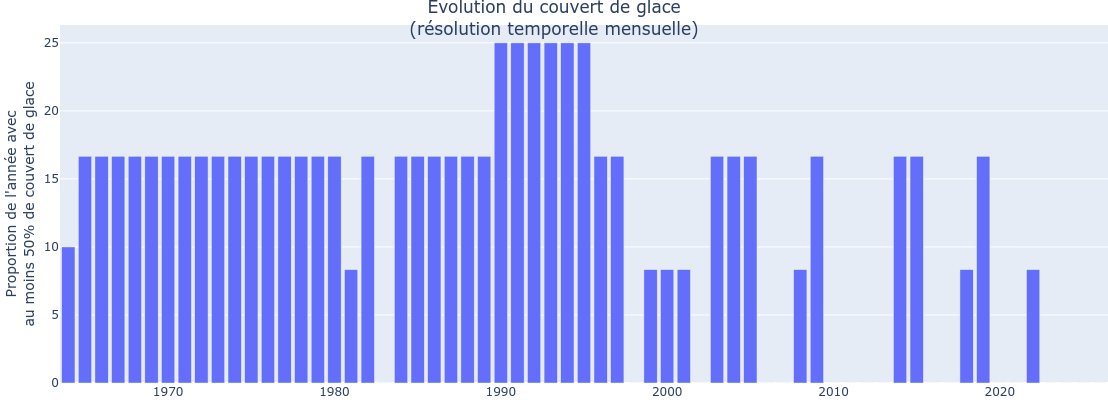

In [169]:
fig = create_ice_cover_plot(monthly_era5)
fig.write_image(figures_dir / "ice_cover.svg")
fig.show()

## Détermination de la tempête de conception

In [4]:
wind_threshold = 10
duration_threshold = 6
storms = extract_storms(
    latest,
    wind_threshold=wind_threshold,
    duration_threshold=duration_threshold,
)

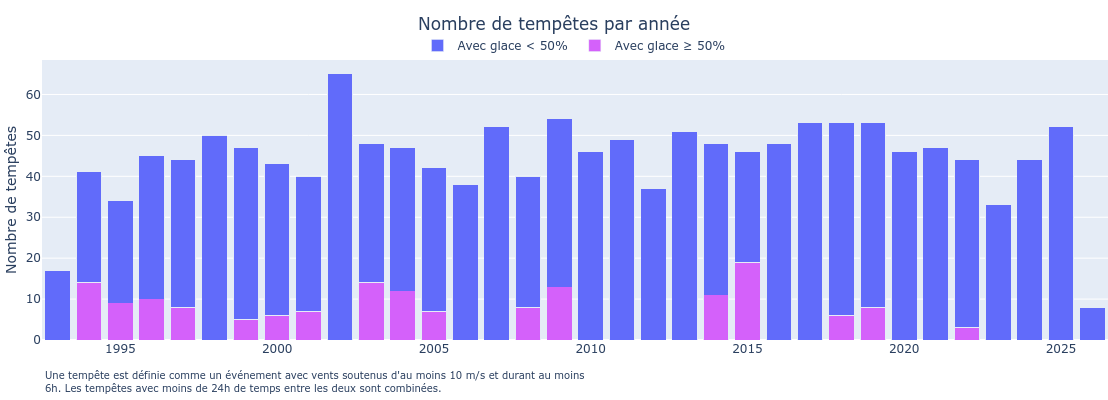

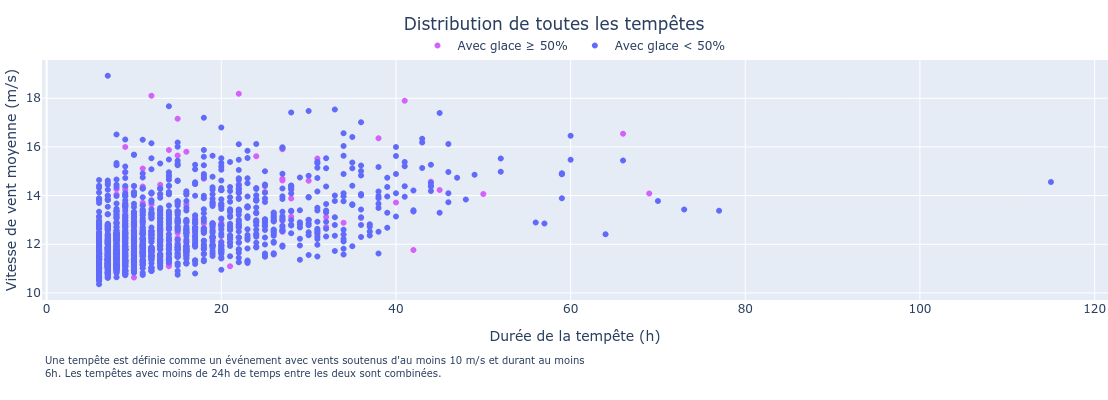

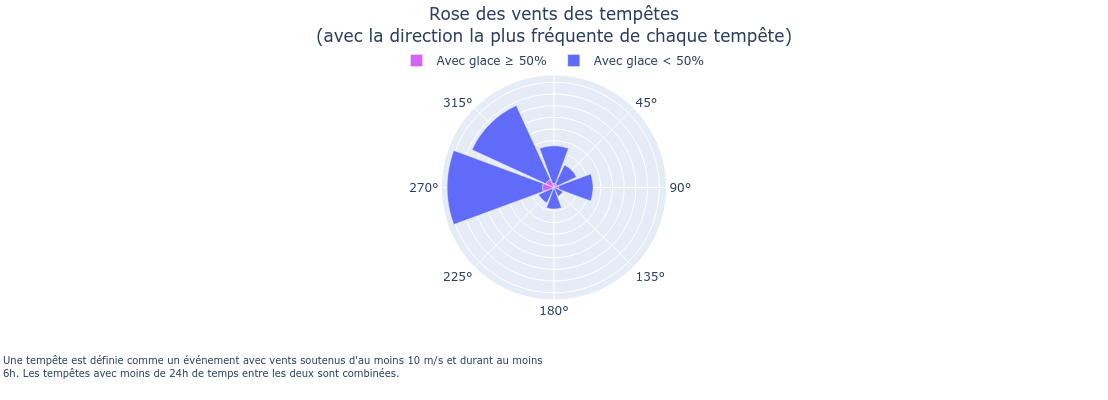

In [78]:
n_fig = create_storm_years_fig(
    storms,
    wind_threshold=wind_threshold,
    duration_threshold=duration_threshold,
)
intensity_fig = create_storm_intensity_fig(
    storms,
    wind_threshold=wind_threshold,
    duration_threshold=duration_threshold,
)
wind_rose_fig = create_storm_wind_rose(
    storms,
    wind_threshold=wind_threshold,
    duration_threshold=duration_threshold,
)
n_fig.write_image(figures_dir / "storm_n.svg")
intensity_fig.write_image(figures_dir / "storm_intensity.svg")
wind_rose_fig.write_image(figures_dir / "storm_wind_rose.svg")
n_fig.show()
intensity_fig.show()
wind_rose_fig.show()

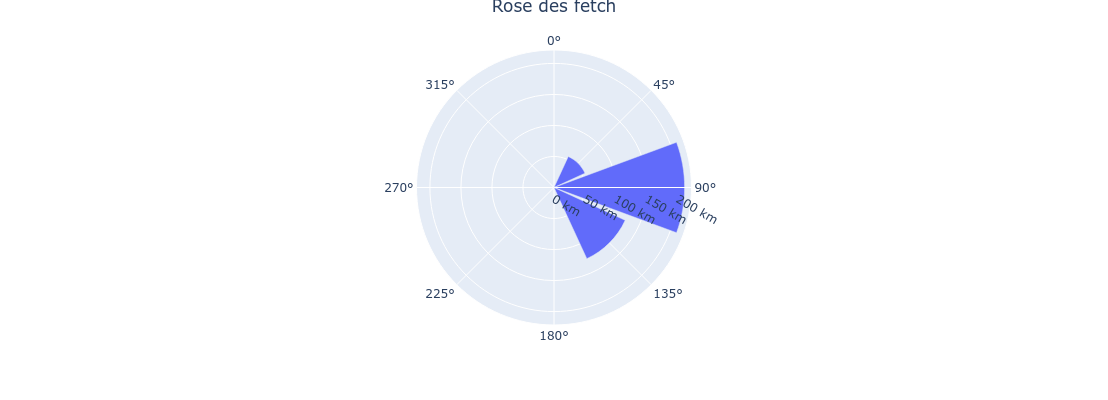

In [79]:
fetch_fig = create_fetch_wind_rose(fetch)
fetch_fig.write_image(figures_dir / "fetch.svg")
fetch_fig.show()

In [5]:
east_storms = storms.filter(pl.col("wind_direction").is_in([90, 135]))

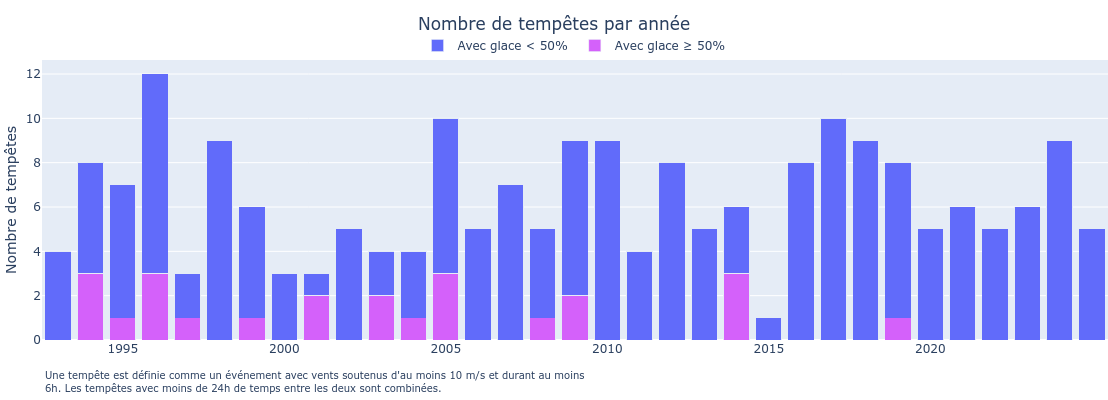

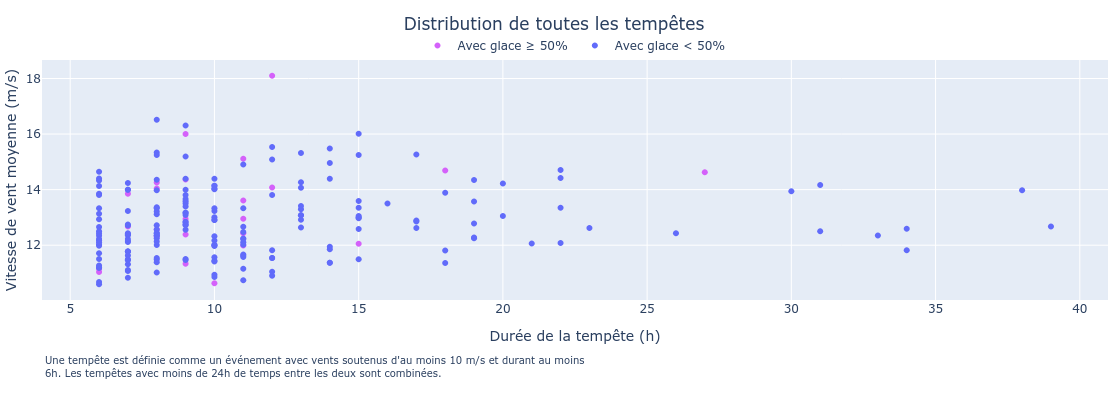

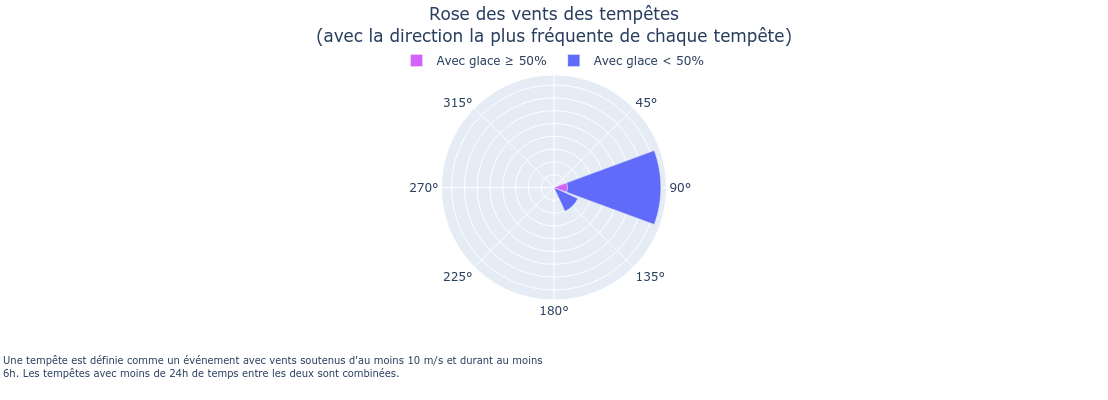

In [77]:
n_fig = create_storm_years_fig(
    east_storms,
    wind_threshold=wind_threshold,
    duration_threshold=duration_threshold,
)
intensity_fig = create_storm_intensity_fig(
    east_storms,
    wind_threshold=wind_threshold,
    duration_threshold=duration_threshold,
)
wind_rose_fig = create_storm_wind_rose(
    east_storms,
    wind_threshold=wind_threshold,
    duration_threshold=duration_threshold,
)
n_fig.write_image(figures_dir / "east_storm_n.svg")
intensity_fig.write_image(figures_dir / "east_storm_intensity.svg")
wind_rose_fig.write_image(figures_dir / "east_storm_wind_rose.svg")
n_fig.show()
intensity_fig.show()
wind_rose_fig.show()

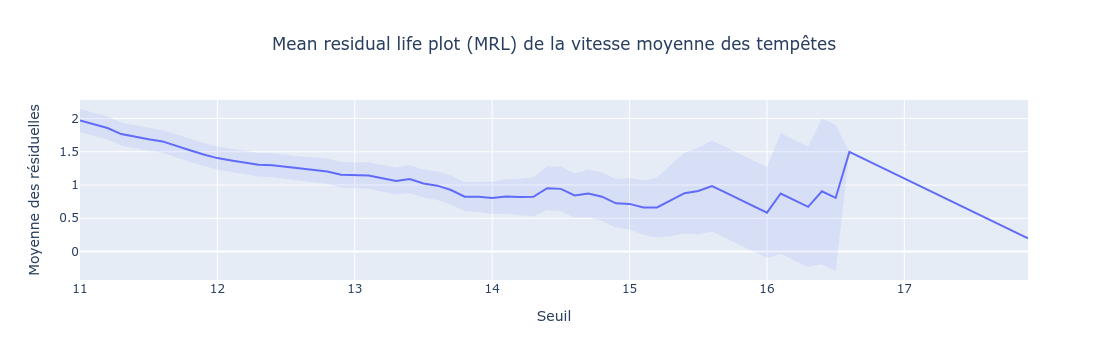

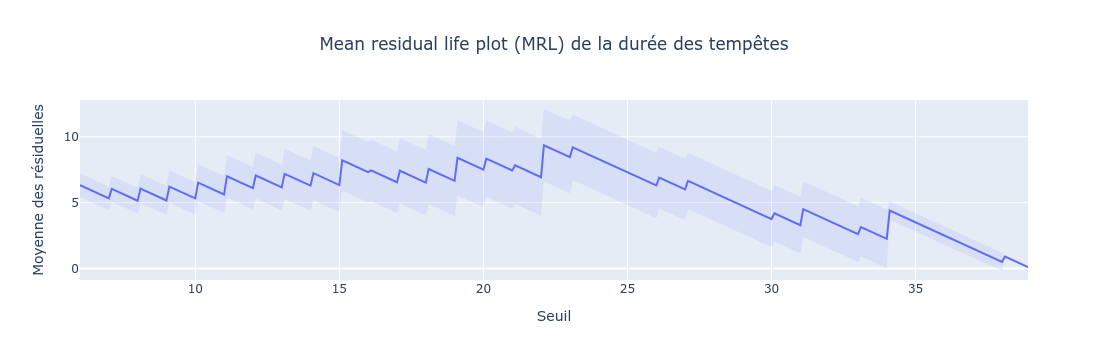

In [17]:
mrl_wind_speed_fig = create_mean_residual_life_fig(
    east_storms,
    "wind_speed_mean",
    title="Mean residual life plot (MRL) de la vitesse moyenne des tempêtes",
    threshold=13.8,
)
mrl_duration_fig = create_mean_residual_life_fig(
    east_storms,
    "duration",
    title="Mean residual life plot (MRL) de la durée des tempêtes",
)
mrl_wind_speed_fig.show()
mrl_duration_fig.show()